In [2]:
from minio import Minio
import s3fs
import os
import matplotlib.pyplot as plt
import xarray as xr
import pickle
import numpy as np
from sympl import get_constant
import metpy
from metpy.units import units
import matplotlib.pylab as pl
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import ScalarFormatter

fs = s3fs.S3FileSystem(
    client_kwargs={
        "endpoint_url": "http://192.168.1.237:9000"
    },
    key="d0d250b2541ac33f4660",
    secret="2fb32d964768bc94a3c0"
)
output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/1/'
base_path = "abel-long-run/aqua-planet/regridded-data/"
plot_path = '/home/data/lab_project2/Steve/model_runs/plotting/ap-plots/1/'
Rd = get_constant('gas_constant_of_dry_air', 'J kg^-1 K^-1')
Cp =\
    get_constant('heat_capacity_of_dry_air_at_constant_pressure',
                 'J kg^-1 K^-1')
g=get_constant('gravitational_acceleration',
                 'm s^-2')
DSE2T50 = 0.000872245848416538
DSE2T35 = 0.0009613611785908903

dsetot 3.530474164132747e-15 3.0037546554857244e-15
dseyca 1.33908286842934e-14 6.8640917417086194e-15
dseyaa -4.521217856333316e-15 5.55040148159814e-15
dsexac 1.1165997336987515e-15 2.9627467438848584e-15
dsexaa -8.931164327668125e-16 2.8628850809434433e-15
dsez -5.799195297535723e-15 2.719639179472947e-15
dseres -1.8345500833815112e-15 2.6081405193862103e-15
dsetot 2.1942638594897285e-15 2.5207349657590622e-15
dseyca 9.48939403436747e-15 5.308216642546622e-15
dseyaa -3.004540512593992e-15 3.97000999018236e-15
dsexac -1.8862802433252566e-16 3.610248641599971e-16
dsexaa -3.166360240000226e-16 2.52509821905386e-15
dsez -3.6783695090861346e-15 2.1663960047052526e-15
dseres -8.726686611264355e-16 2.1869400153821017e-15
dsetot 2.6947630017094165e-15 2.756415330834915e-15
dseyca 9.313559948318024e-15 5.950210049792263e-15
dseyaa -4.0794934373413854e-15 5.445695912119935e-15
dsexac 1.0039266427500152e-15 4.078005968071385e-15
dsexaa -4.472503974112779e-16 5.3065072211646175e-15
dsez -3.2875

/tmp/ipykernel_695392/1621457879.py:131: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_695392/1621457879.py:132: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_695392/1621457879.py:133: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_695392/16

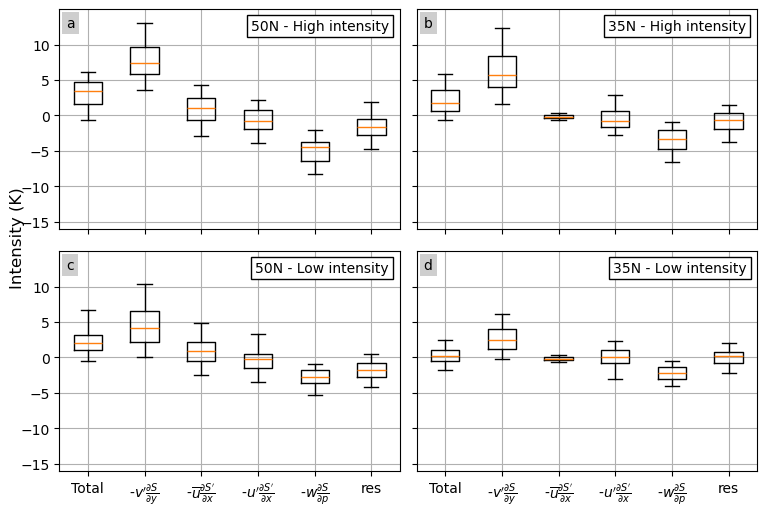

In [5]:
with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    rey_HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    rey_HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    rey_LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    rey_LI_35 = pickle.load(f)
    
##########################F#################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])
low_lim, up_lim = -16, 15

######################### high intensity lat 50 ###########################
dse_master=rey_HI_50
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)

# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T50 * np.array(arr)).tolist() for arr in x ]
ax1.boxplot(x, showfliers=False, whis=(5,95))
ax1.grid()
ax1.set_xticklabels([])
#ax1.yaxis.set_major_formatter(formatter)
ax1.autoscale(axis='y')
ax1.set_ylim(low_lim,up_lim)
ax1.yaxis.get_major_locator().set_params(prune='both')
set_label(fig, ax1, 'a')


####################### high intensity lat 35 #############################
dse_master=rey_HI_35
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)
#x = np.array(x)
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T35 * np.array(arr)).tolist() for arr in x ]
ax2.boxplot(x, showfliers=False, whis=(5,95))
ax2.grid()
ax2.set_xticklabels([])
#ax2.yaxis.set_major_formatter(formatter)
ax2.autoscale(axis='y')
ax2.set_ylim(low_lim, up_lim)
ax2.yaxis.get_major_locator().set_params(prune='both')
set_label(fig,ax2, 'b')
ax2.set_yticklabels([])

###################### low intensity lat 50 ###############################
dse_master=rey_LI_50
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)
#x = np.array(x)
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T50 * np.array(arr)).tolist() for arr in x ]
ax3.boxplot(x, showfliers=False, whis=(5,95))
ax3.grid()
ax3.autoscale(axis='y')
ax3.set_ylim(low_lim, up_lim)
ax3.yaxis.get_major_locator().set_params(prune='both')
#ax3.yaxis.set_major_formatter(formatter)
set_label(fig,ax3, 'c')
ax3.set_xticks([1, 2, 3, 4, 5, 6], ['Total', r'-$v^\prime\frac{\partial S}{\partial y}$',
                                r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
                                r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
                                r'-$w\frac{\partial S}{\partial p}$',
                                'res'])

###################### low intensity lat 35 ###############################
dse_master=rey_LI_35
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)

x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T35 * np.array(arr)).tolist() for arr in x ]
ax4.boxplot(x, showfliers=False, whis=(5,95))
ax4.grid()
#ax4.yaxis.set_major_formatter(formatter)
ax4.autoscale(axis='y')
ax4.set_ylim(low_lim, up_lim)
set_label(fig,ax4, 'd')
ax4.set_yticklabels([])
ax4.yaxis.get_major_locator().set_params(prune='both')
ax4.set_xticks([1, 2, 3, 4, 5, 6], ['Total', r'-$v^\prime\frac{\partial S}{\partial y}$',
                                r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
                                r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
                                r'-$w\frac{\partial S}{\partial p}$',
                                'res'])


ax1.annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("35N - Low intensity",xy=(0.575,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supylabel("Intensity (K)", fontsize=12, x=0.07)

fig.savefig(plot_path+'4.pdf', bbox_inches='tight')
#fig.savefig(plot_path+'4.jpg',dpi=600, bbox_inches='tight')

In [5]:
with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    rey_LI_35 = pickle.load(f)
    
with open(output_dir+'hw_35', 'rb') as f:
    hw_35 = pickle.load(f)

In [6]:
len(rey_LI_35['index'])

72

In [18]:
hw_master = hw_35
target_lons = [105]

mask = [lon in target_lons for lon in hw_master['lonc']]
hw_master = {key: [vals[i] for i, m in enumerate(mask) if m]
               for key, vals in hw_master.items()}

In [20]:
len(hw_master['index'])

177

In [7]:
output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/1/scratch/'
with open(output_dir+'dse_mean_50', 'rb') as f:
    rey_LI_35 = pickle.load(f)
    

In [9]:
len(rey_LI_35['index'])


105